# pic0rick RP2350 DSP firmware — step-by-step example

Targets the **`-DDSP`** firmware build (see `docs/dsp_test_guide.md`). Run the
cells top to bottom.

Shows the **raw text replies from the Pico** (parameters + per-stage DSP µs
times) alongside the decoded captures, **arms the pulser from the start**, covers
**raw / Hilbert-envelope / A-law**, runs the DSP **self-test**, checks the
**pulser order**, and **saves every capture to files** (`captures/<name>/`:
`<payload>.npy`, `header.json`, `status.txt`).

Requires: `pyserial`, `numpy`, `matplotlib`.

## 1. Imports

In [32]:
%matplotlib inline
import os, re, json, dataclasses
import numpy as np
import matplotlib.pyplot as plt
from pic0rick.device import Pic0rick
from pic0rick import dsp

## 2. Connect

`PORT = None` auto-detects the USB-CDC port.

In [33]:
PORT = None
probe = Pic0rick(port=PORT, verbose=False)

Device on /dev/ttyACM0


## 3. Version

In [34]:
print(probe.version()['raw'])

pic0rick firmware v0.1.11
changes: Fix MUX/pulser PIO1 conflict: max14866_init hardcoded sm0, clobbering the pulser drive SM (pio1 sm0) claimed by the acquisition -- so MUX builds produced no transmit pulse / no echo. Now claims an unused SM. Restores echoes on MUX builds.
board:   pico2 (RP2350)
mux:     enabled (MAX14866)
build:   99e7b23-dirty
release: https://github.com/kelu124/pic0rick/releases/tag/fw-v0.1.11



## 4. Status

The Pico's exact `status` line, then a readable breakdown (parameters +
per-stage DSP µs). Only works on a DSP build.

In [35]:
st = probe.status()
print('Pico reply:')
print(' ', st['raw'])
print()
print(dsp.describe_status(st))

Pico reply:
  OK board=pic0rick package=RP2350A firmware=0.1.11 dsp_backend=f32-rfft-hilbert samples=4096 sample_rate=60000000 pulser=disarmed pulse=96/6000/96/neg-first dac=50 scale=512.000 stream=off/0 drops=0 stages_us=0/0/0/0/0/0 dsp_us=0 worst_us=0 performance=ok envelope_max_rate=50 alaw_max_rate=70 cmsis=1.17.0

pic0rick status
  board/package    pic0rick / RP2350A
  firmware         0.1.11
  dsp backend      f32-rfft-hilbert
  cmsis-dsp        1.17.0
  acquisition      4096 samples @ 60 MS/s
  pulser           disarmed
  pulse (ns)       neg 96 / damp 6000 / pos 96, neg-first
  dac / scale      50 / 512.0
  stream           off @ 0 Hz
  dropped frames   0
  DSP stage times (us):
      preprocess   0
      forward_fft  0
      mask         0
      inverse_fft  0
      magnitude    0
      alaw         0
  dsp_us / worst   0 / 0 (ok)
  max rates (Hz)   envelope 50, alaw 70


## 5. Commands (`help`)

In [36]:
def send(cmd, wait=0.4):
    """Send a text command, print and return the Pico's reply. Do NOT use for
    commands that stream binary frames (selftest / captures)."""
    probe.ser.write((cmd + '\n').encode('ascii'))
    reply = ''.join(b.decode('utf-8', 'replace') for b in probe.sread()).strip()
    print(cmd, '->', reply)
    return reply

send('help')

help -> OK commands=status|help|version|reboot-dfu|pulser arm|pulser disarm|pulse config <negative_ns> <damp_ns> <positive_ns> <neg-first|pos-first>|dac write <0..1023>|dsp scale <reference>|dsp selftest|acq <raw|envelope|alaw>|read_raw|read_fft|stream start <raw|envelope|alaw> <rate_hz>|stream stop|write mux <hex>|set mux|clear mux|start acq|read


'OK commands=status|help|version|reboot-dfu|pulser arm|pulser disarm|pulse config <negative_ns> <damp_ns> <positive_ns> <neg-first|pos-first>|dac write <0..1023>|dsp scale <reference>|dsp selftest|acq <raw|envelope|alaw>|read_raw|read_fft|stream start <raw|envelope|alaw> <rate_hz>|stream stop|write mux <hex>|set mux|clear mux|start acq|read'

## 6. Set gain and ARM the pulser (from the start)

The pulser is armed here so **every capture below transmits**. The DSP build's
gain command is `dac write <n>` (0..1023).

In [37]:
GAIN = 50            # TGC DAC value 0..1023
send(f'dac write {GAIN}')
send('dsp scale 512')                       # A-law full-scale reference (ADC counts)
send('pulse config 96 6000 96 neg-first')   # neg/damp/pos ns, order
send('pulser arm')

dac write 50 -> OK dac=50
dsp scale 512 -> OK scale=512.000
pulse config 96 6000 96 neg-first -> OK pulse=96/6000/96/neg-first
pulser arm -> OK pulser armed


'OK pulser armed'

## 7. Capture helper (saves to files)

`grab(payload, name)` captures one frame, prints the Pico reply + header,
**saves** `../docs/data/dsp_captures/<name>/<payload>.npy` + `header.json` + `status.txt`, and
returns `(frame, samples)`.

In [38]:
CAPT = '../docs/data/dsp_captures'

def grab(payload, name):
    frame = probe.capture(payload)          # 'raw' | 'envelope' | 'alaw'
    s = frame.samples()
    h = frame.header
    print('Pico reply:', probe.last_reply)
    print('  header: samples=%d bytes=%d dc_mean=%.1f envelope_peak=%.1f seq=%d'
          % (h.sample_count, h.payload_bytes, h.adc_dc_mean, h.envelope_peak, h.sequence))
    d = os.path.join(CAPT, name)
    os.makedirs(d, exist_ok=True)
    np.save(os.path.join(d, f'{payload}.npy'), s)
    with open(os.path.join(d, 'header.json'), 'w') as f:
        json.dump(dataclasses.asdict(h), f, indent=2)
    with open(os.path.join(d, 'status.txt'), 'w') as f:
        f.write(dsp.describe_status(probe.status()))
    print('  saved ->', d, '(%s.npy, header.json, status.txt)' % payload)
    return frame, s

## 8. `read_raw` — 8000 raw ADC samples (no FFT)

Pico reply: OK capture started type=raw samples=8000
  header: samples=8000 bytes=16000 dc_mean=549.6 envelope_peak=0.0 seq=91
  saved -> ../docs/data/dsp_captures/raw (raw.npy, header.json, status.txt)
  data: min/mean/max = 0/549/1023


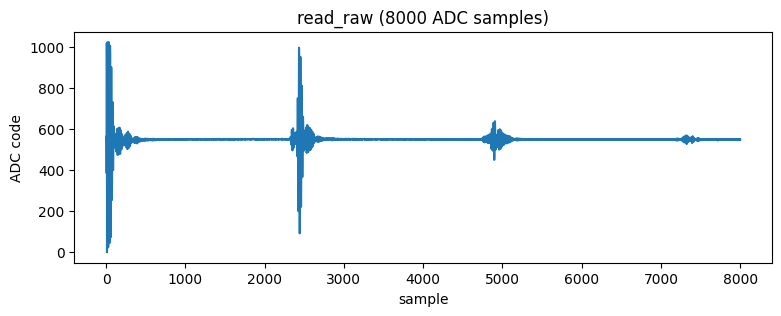

In [39]:
_, raw = grab('raw', 'raw')
print('  data: min/mean/max = %d/%d/%d' % (int(raw.min()), int(raw.mean()), int(raw.max())))
plt.figure(figsize=(9, 3)); plt.plot(raw)
plt.title('read_raw (8000 ADC samples)'); plt.xlabel('sample'); plt.ylabel('ADC code'); plt.show()

## 9. `read_fft` — 4096-sample Hilbert envelope

After the capture, the `status` breakdown shows the **per-stage DSP µs** for the
frame that just ran.

Pico reply: OK capture started type=envelope samples=4096
  header: samples=4096 bytes=16384 dc_mean=546.9 envelope_peak=898.3 seq=92
  saved -> ../docs/data/dsp_captures/envelope (envelope.npy, header.json, status.txt)

pic0rick status
  board/package    pic0rick / RP2350A
  firmware         0.1.11
  dsp backend      f32-rfft-hilbert
  cmsis-dsp        1.17.0
  acquisition      4096 samples @ 60 MS/s
  pulser           armed
  pulse (ns)       neg 96 / damp 6000 / pos 96, neg-first
  dac / scale      50 / 512.0
  stream           off @ 0 Hz
  dropped frames   0
  DSP stage times (us):
      preprocess   540
      forward_fft  4402
      mask         159
      inverse_fft  4549
      magnitude    1065
      alaw         0
  dsp_us / worst   10720 / 11550 (over-budget)
  max rates (Hz)   envelope 50, alaw 70


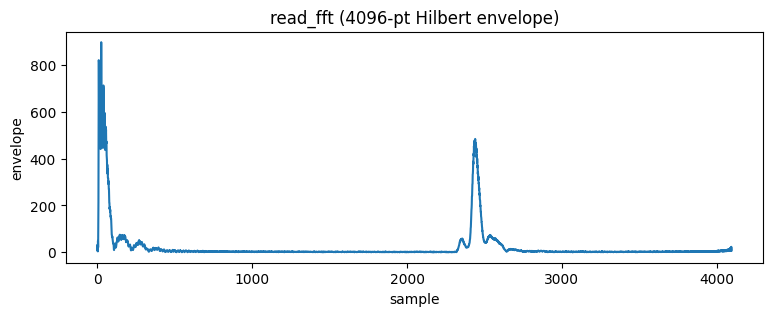

In [40]:
_, env = grab('envelope', 'envelope')
print()
print(dsp.describe_status(probe.status()))
plt.figure(figsize=(9, 3)); plt.plot(env)
plt.title('read_fft (4096-pt Hilbert envelope)'); plt.xlabel('sample'); plt.ylabel('envelope'); plt.show()

## 10. A-law — compressed envelope

`acq alaw` returns the envelope A-law-compressed to `uint8`. Decode it back to
ADC-count amplitude with `dsp.alaw_decode(bytes, reference)` and overlay it on
the float Hilbert envelope from step 9 — they should track closely.

Pico reply: OK capture started type=alaw
  header: samples=4096 bytes=4096 dc_mean=545.5 envelope_peak=913.0 seq=93
  saved -> ../docs/data/dsp_captures/alaw (alaw.npy, header.json, status.txt)
  alaw uint8 min/max = 4/255  reference=512.0


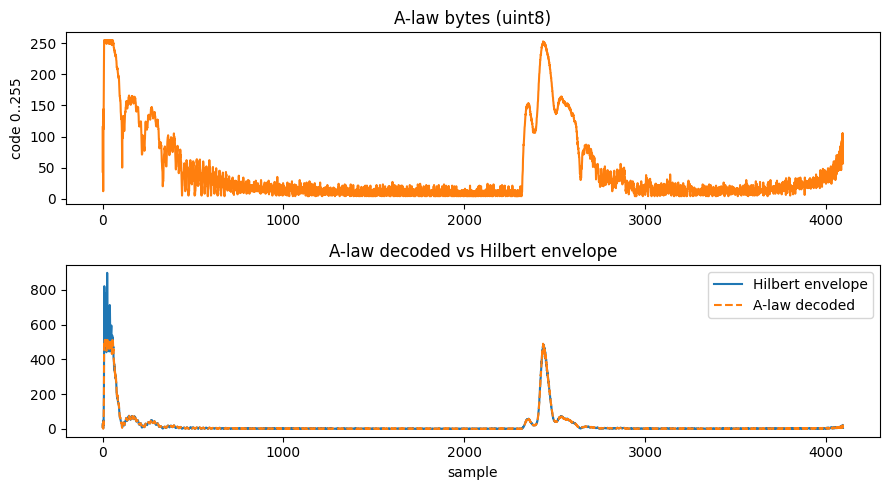

In [41]:
alaw_frame, alaw = grab('alaw', 'alaw')
reference = alaw_frame.header.alaw_reference
decoded = dsp.alaw_decode(alaw, reference)
print('  alaw uint8 min/max = %d/%d  reference=%.1f' % (int(alaw.min()), int(alaw.max()), reference))
fig, ax = plt.subplots(2, 1, figsize=(9, 5))
ax[0].plot(alaw, color='tab:orange'); ax[0].set_title('A-law bytes (uint8)'); ax[0].set_ylabel('code 0..255')
ax[1].plot(env, label='Hilbert envelope')
ax[1].plot(decoded, '--', label='A-law decoded')
ax[1].set_title('A-law decoded vs Hilbert envelope'); ax[1].set_xlabel('sample'); ax[1].legend()
fig.tight_layout(); plt.show()

## 11. DSP self-test

`dsp selftest` streams deterministic synthetic vectors (7 cases x raw/envelope/
alaw) — a firmware-only check of the DSP pipeline. We read the frames directly
with a `FrameReader`.

In [42]:
probe.ser.reset_input_buffer()
probe.ser.write(b'dsp selftest\n')
ok = probe.ser.readline().decode('utf-8', 'replace').strip()
print('Pico reply:', ok)
n = int(re.search(r'frames=(\d+)', ok).group(1))
reader = dsp.FrameReader(probe.ser)
frames = [reader.read_frame() for _ in range(n)]
print('read %d self-test frames' % len(frames))
for f in frames:
    if f.header.payload_name == 'envelope':
        print('  case %d %-10s envelope_peak=%.1f'
              % (f.header.selftest_case, dsp.SELFTEST_NAMES[f.header.selftest_case]
                 if f.header.selftest_case < len(dsp.SELFTEST_NAMES) else '?', f.header.envelope_peak))

Pico reply: OK selftest frames=21 cases=7
read 21 self-test frames
  case 0 zero       envelope_peak=0.0
  case 1 dc         envelope_peak=0.0
  case 2 sinusoid   envelope_peak=200.7
  case 3 am         envelope_peak=314.0
  case 4 two-bursts envelope_peak=359.1
  case 5 impulse    envelope_peak=510.9
  case 6 clipping   envelope_peak=1276.7


## 12. Pulser order check

Capture a raw trace with each polarity order and compare the transmit region.

pulse config 96 6000 96 pos-first -> OK pulse=96/6000/96/pos-first
pulse config 96 6000 96 neg-first -> OK pulse=96/6000/96/neg-first


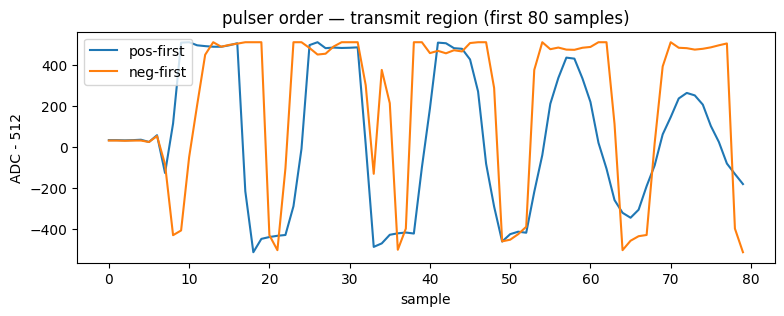

In [43]:
send('pulse config 96 6000 96 pos-first')
raw_pos = probe.read_raw().samples().astype(int) - 512
send('pulse config 96 6000 96 neg-first')
raw_neg = probe.read_raw().samples().astype(int) - 512
plt.figure(figsize=(9, 3))
plt.plot(raw_pos[:80], label='pos-first')
plt.plot(raw_neg[:80], label='neg-first')
plt.title('pulser order — transmit region (first 80 samples)')
plt.xlabel('sample'); plt.ylabel('ADC - 512'); plt.legend(); plt.show()

## 13. Saved files

In [44]:
for root, _, files in sorted(os.walk(CAPT)):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        print('%8d  %s' % (os.path.getsize(p), p))

    4224  ../docs/data/dsp_captures/alaw/alaw.npy
     405  ../docs/data/dsp_captures/alaw/header.json
     599  ../docs/data/dsp_captures/alaw/status.txt
   16512  ../docs/data/dsp_captures/envelope/envelope.npy
     404  ../docs/data/dsp_captures/envelope/header.json
     597  ../docs/data/dsp_captures/envelope/status.txt
     391  ../docs/data/dsp_captures/raw/header.json
   16128  ../docs/data/dsp_captures/raw/raw.npy
     567  ../docs/data/dsp_captures/raw/status.txt


## 14. Disarm the pulser

In [45]:
send('pulser disarm')

pulser disarm -> OK pulser disarmed


'OK pulser disarmed'

---
See `docs/dsp_test_guide.md` for the full command set, `pic0rick.dsp` for the
protocol, and `python/example_dsp.py` for a script version. A-law needs
`dsp.SELFTEST_NAMES` / `alaw_decode` from `pic0rick.dsp`.